# 04 - Đánh giá & So sánh mô hình
BTL môn Trí tuệ nhân tạo — Dự đoán khả năng Đỗ/Trượt của sinh viên

## Bước 1: Load lại models và data test

In [1]:
import joblib

X_train, X_test, y_train, y_test = joblib.load("../data/processed/train_test_data.pkl")
feature_names = joblib.load("../data/processed/feature_names.pkl")

model_names = ["Logistic_Regression", "Decision_Tree", "Random_Forest", "KNN"]
models = {name: joblib.load(f"../results/models/{name}.pkl") for name in model_names}

## Bước 2: Tính các chỉ số đánh giá

In [2]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 3),
        "Precision": round(precision_score(y_test, y_pred), 3),
        "Recall": round(recall_score(y_test, y_pred), 3),
        "F1-score": round(f1_score(y_test, y_pred), 3)
    })

results_df = pd.DataFrame(results)
print(results_df)

results_df.to_csv("../results/comparison_table.csv", index=False)

                 Model  Accuracy  Precision  Recall  F1-score
0  Logistic_Regression     0.893      0.894   0.998     0.943
1        Decision_Tree     0.893      0.893   1.000     0.944
2        Random_Forest     0.863      0.899   0.954     0.926
3                  KNN     0.876      0.897   0.973     0.933


## Bước 3: Vẽ Confusion Matrix cho từng mô hình

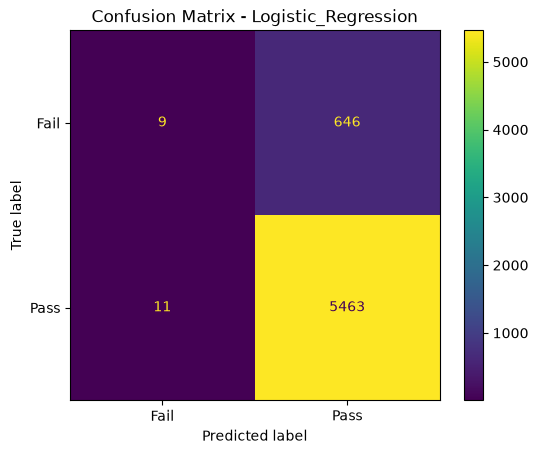

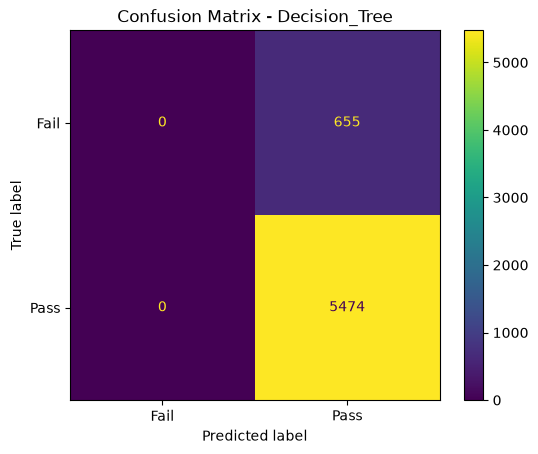

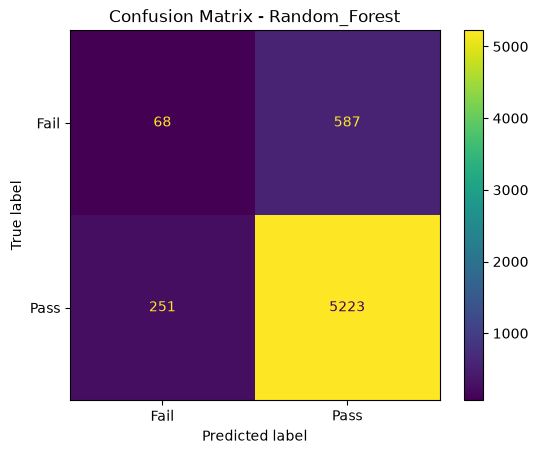

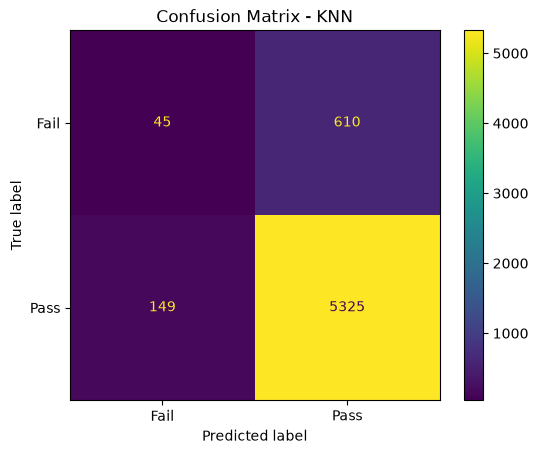

In [3]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import os

os.makedirs("../results/figures", exist_ok=True)

for name, model in models.items():
    y_pred = model.predict(X_test)
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Fail", "Pass"])
    plt.title(f"Confusion Matrix - {name}")
    plt.savefig(f"../results/figures/cm_{name}.png")
    plt.show()

## Bước 4: Vẽ ROC Curve so sánh 4 mô hình

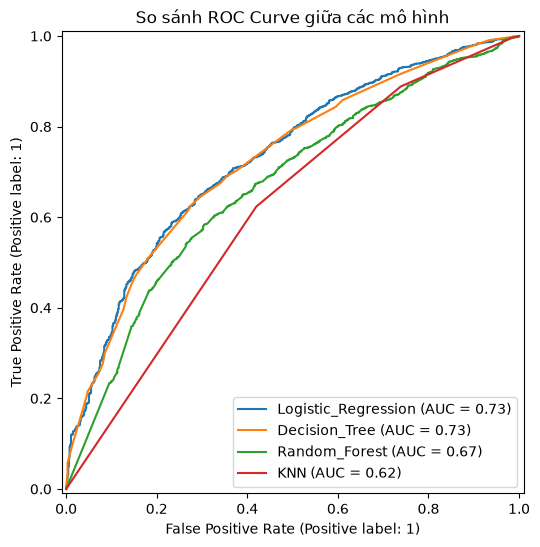

In [4]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8, 6))
for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)

plt.title("So sánh ROC Curve giữa các mô hình")
plt.savefig("../results/figures/roc_comparison.png")
plt.show()

## Bước 5: Feature Importance từ Random Forest

                Feature  Importance
8            NrSiblings    0.219827
2            ParentEduc    0.143413
1           EthnicGroup    0.120176
5   ParentMaritalStatus    0.117630
10       WklyStudyHours    0.089291
6         PracticeSport    0.086538
3             LunchType    0.056878
9        TransportMeans    0.056102
7          IsFirstChild    0.052839
0                Gender    0.029688
4              TestPrep    0.027618


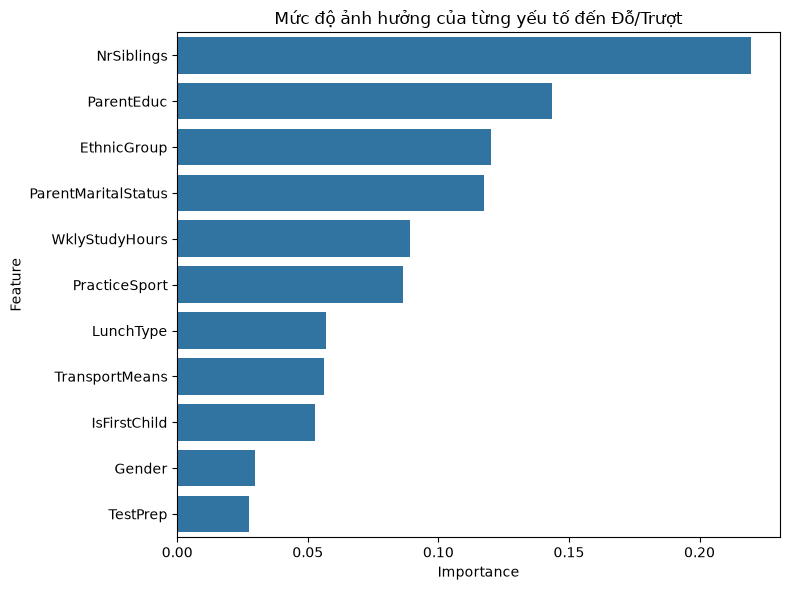

In [5]:
import seaborn as sns

rf_model = models["Random_Forest"]
importances = rf_model.feature_importances_

feat_df = pd.DataFrame({"Feature": feature_names, "Importance": importances})
feat_df = feat_df.sort_values(by="Importance", ascending=False)
print(feat_df)

plt.figure(figsize=(8, 6))
sns.barplot(data=feat_df, x="Importance", y="Feature")
plt.title("Mức độ ảnh hưởng của từng yếu tố đến Đỗ/Trượt")
plt.tight_layout()
plt.savefig("../results/figures/feature_importance.png")
plt.show()

## Bước 6: Biểu đồ so sánh Accuracy giữa các mô hình

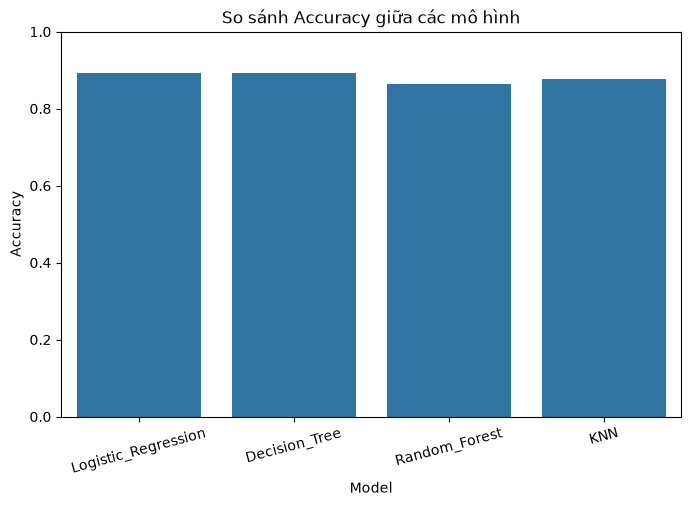

In [6]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="Model", y="Accuracy")
plt.title("So sánh Accuracy giữa các mô hình")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.savefig("../results/figures/accuracy_comparison.png")
plt.show()

## Hoàn tất
Bảng kết quả nằm ở `results/comparison_table.csv`.
Các biểu đồ nằm ở `results/figures/` — dùng để dán vào slide và báo cáo.